# Random Forest Sentiment Classification

# Q2. Supervised Text Classification

## 1. Import libraries and set reproducibility

The fixed random state makes the train/test split, tuning sample, and hyperparameter search reproducible.

In [12]:
import json
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Random Forest classification model
from sklearn.ensemble import RandomForestClassifier

# Text feature extraction used before Random Forest classification
from sklearn.feature_extraction.text import TfidfVectorizer

# Evaluation metrics for measuring classifier performance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
# Hyperparameter tuning, cross-validation, and data splitting
from sklearn.model_selection import (
    RandomizedSearchCV,  # Searches for the best hyperparameter combination
    StratifiedKFold,  # Cross-validation strategy used during tuning
    train_test_split,  # Splits data into training and testing sets
)


from sklearn.pipeline import Pipeline

RANDOM_STATE = 42 # fixed seed to make randomized results reproducible
TEST_SIZE = 0.20 # reserve 20% of the data for testing
TUNING_SAMPLE_SIZE = 12_000 # uses 12000 training reviews for tuning to reduce computation time
SEARCH_ITERATIONS = 8 # random selected hyperparameter combinations
CV_FOLDS = 3 # three cross-validation folds to assess each combination

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 30)


def calculate_binary_metrics(y_true, y_pred, y_probability):
    """Calculate and return the main binary-classification evaluation metrics."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred), # Proportion of correctly classified instances
        "Precision": precision_score(y_true, y_pred, zero_division=0), # Proportion of positive predictions that are correct
        "Recall": recall_score(y_true, y_pred, zero_division=0), # Proportion of actual positives that are correctly identified
        "F1-score": f1_score(y_true, y_pred, zero_division=0), # Harmonic mean of precision and recall
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0), # Macro-averaged F1-score
        "ROC-AUC": roc_auc_score(y_true, y_probability), # Measures how well the model distinguishes between classes
    }


print("Libraries imported successfully.")
print(f"Random state: {RANDOM_STATE}")

Libraries imported successfully.
Random state: 42


## 2. Load and validate the cleaned dataset

The earlier data-preparation work produced:

- `final_review`: cleaned review text used as the predictor.
- `label`: sentiment target, where 0 is negative and 1 is positive.

Only these modelling fields are loaded to reduce memory usage.

In [13]:
# Candidate paths allow the notebook to run from either its own folder or the TXSA source/project directory.
candidate_paths = [
    Path("../txsa_p2/txsa_p2/imdb_cleaned.csv"),
    Path("TSXA/txsa_p2/txsa_p2/imdb_cleaned.csv"),
    Path("txsa_p2/txsa_p2/imdb_cleaned.csv"),
]
data_path = next((path.resolve() for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find imdb_cleaned.csv. Check the candidate paths in this cell."
    )

df = pd.read_csv(data_path, usecols=["final_review", "label"])

print(f"Dataset: {data_path}")
print(f"Loaded shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head(3))

Dataset: C:\Users\ggshe\OneDrive - Asia Pacific University of Technology And Innovation (APU)\APU - Year 3\TXSA\source\TSXA\txsa_p2\txsa_p2\imdb_cleaned.csv
Loaded shape: 50,000 rows x 2 columns


,label,final_review
0,1,one reviewer mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality...
1,1,wonderful little production filming technique unassuming oldtimebbc fashion give comforting sometimes discomforting ...
2,1,thought wonderful way spend time hot summer weekend sitting air conditioned theater watching lighthearted comedy plo...


In [14]:
# Rename the text field and validate the modelling data and create dataframe
model_df = df.rename(columns={"final_review": "text"}).copy()

# remove rows with missing text or label
model_df = model_df.dropna(subset=["text", "label"])

# convert reviews to string and remove leading/trailing whitespace
model_df["text"] = model_df["text"].astype(str).str.strip()

# remove rows with empty text
model_df = model_df.loc[model_df["text"].ne("")].copy()

# convert label to integer
model_df["label"] = model_df["label"].astype(int)


# confirm label only contains 0 and 1
if not set(model_df["label"].unique()).issubset({0, 1}):
    raise ValueError("The label column must contain only 0 and 1.")

# check for duplicate texts with conflicting labels. 
# conflicting labels would make correct target for a review unclear.
conflicting_texts = model_df.groupby("text")["label"].nunique().gt(1).sum()
if conflicting_texts:
    raise ValueError(
        f"Found {conflicting_texts} duplicate texts with conflicting labels."
    )

rows_before = len(model_df)

# remove exact duplicate reviews (same text and label)
model_df = model_df.drop_duplicates(subset="text").reset_index(drop=True)
duplicates_removed = rows_before - len(model_df)

# count of reviews by class and percentage of total reviews
class_summary = (
    model_df["label"]
    .value_counts()
    .sort_index()
    .rename(index={0: "negative (0)", 1: "positive (1)"})
    .rename("reviews")
    .to_frame()
)
class_summary["percentage"] = (
    class_summary["reviews"] / class_summary["reviews"].sum() * 100
).round(2)

print(f"Missing/empty rows removed: {len(df) - rows_before:,}")
print(f"Exact duplicate reviews removed: {duplicates_removed:,}")
print(f"Rows available for modelling: {len(model_df):,}")
display(class_summary)

Missing/empty rows removed: 0
Exact duplicate reviews removed: 423
Rows available for modelling: 49,577


,reviews,percentage
label,,
negative (0),24695,49.81
positive (1),24882,50.19


## 3. Create a held-out stratified train/test split

The test set is isolated before TF-IDF fitting and hyperparameter selection. It is used only for the final Q4 evaluation. Stratification preserves the nearly equal class distribution.

In [ ]:
# Hold out 20% before TF-IDF fitting so test reviews cannot affect the vocabulary or IDF weights.
# Stratification preserves the sentiment ratio; X is review text and y is the binary label.
X_train, X_test, y_train, y_test = train_test_split(
    model_df["text"],               # Input features: cleaned review text
    model_df["label"],              # Target variable: sentiment label (0=negative, 1=positive)
    test_size=TEST_SIZE,            # Percentage of data reserved for testing
    random_state=RANDOM_STATE,      # Ensure the same split each time 
    stratify=model_df["label"],     # Preserves the original class distribution
)

# summary table for number of reviews and class distribution in training and test sets
split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "negative": [(y_train == 0).sum(), (y_test == 0).sum()],
        "positive": [(y_train == 1).sum(), (y_test == 1).sum()],
    },
    index=["Training set", "Held-out test set"],
)

display(split_summary)

,rows,negative,positive
Training set,39661,19756,19905
Held-out test set,9916,4939,4977


## 4. Build the baseline TF-IDF + Random Forest model

- **TF-IDF** converts review text into numeric features and reduces the weight of terms that occur in many documents.
- Unigrams and bigrams capture both individual terms and short phrases.
- The pipeline fits TF-IDF on training text only, preventing held-out test leakage.

In [ ]:
# Convert the reviews into at most 30,000 unigram and bigram TF-IDF features.
TFIDF_PARAMETERS = {
    "ngram_range": (1, 2),      #  use unigrams and bigrams
    "min_df": 2,                # ignore terms that appear in fewer than 2 documents
    "max_df": 0.95,             # ignore terms that appear in more than 95% of documents
    "max_features": 30_000,     # limit the number of features to 30,000
    "sublinear_tf": True,       # apply logarithmic scaling to term frequencies
    "dtype": np.float32,        # use 32-bit floats to save memory
}

# Configure the 300-tree baseline; balanced_subsample recalculates class weights for each tree.
BASELINE_RF_PARAMETERS = {
    "n_estimators": 300,        # build 300 decision trees in the forest
    "min_samples_leaf": 2,      # require at least 2 samples in each leaf node
    "max_features": "sqrt",     # test the square root of the number of features at each split
    "class_weight": "balanced_subsample",   # adjust class weights for each tree's sample
    "random_state": RANDOM_STATE,           # ensure reproducibility of results
    "n_jobs": -1,                           # use all available CPU cores for training
}


# Keep TF-IDF and Random Forest in one pipeline so vectorisation is fitted only on training data.
baseline_pipeline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(**TFIDF_PARAMETERS)),
        ("random_forest", RandomForestClassifier(**BASELINE_RF_PARAMETERS)),
    ]
)

# Fit the complete pipeline on training reviews and record its training time.
baseline_fit_start = perf_counter()
baseline_pipeline.fit(X_train, y_train)
baseline_fit_seconds = perf_counter() - baseline_fit_start

# Evaluate once on held-out reviews using class predictions and positive-class probabilities.
baseline_predict_start = perf_counter()
baseline_pred = baseline_pipeline.predict(X_test)
baseline_probability = baseline_pipeline.predict_proba(X_test)[:, 1]
baseline_predict_seconds = perf_counter() - baseline_predict_start
baseline_metrics = calculate_binary_metrics(
    y_test, baseline_pred, baseline_probability
)

# Confirm the fitted vocabulary size and display the required performance measures.
feature_count = len(
    baseline_pipeline.named_steps["tfidf"].get_feature_names_out()
)
print(f"Baseline training time: {baseline_fit_seconds:,.2f} seconds")
print(f"Baseline prediction time: {baseline_predict_seconds:,.2f} seconds")
print(f"TF-IDF features used: {feature_count:,}")
display(
    pd.DataFrame.from_dict(
        baseline_metrics, orient="index", columns=["Baseline test score"]
    ).round(4)
)

Baseline training time: 47.31 seconds
Baseline prediction time: 3.22 seconds
TF-IDF features used: 30,000


,Baseline test score
Accuracy,0.8593
Precision,0.8517
Recall,0.8714
F1-score,0.8615
Macro F1,0.8593
ROC-AUC,0.9361


# Q3. Hyperparameter Selection

## 5. Random Forest hyperparameters and their effects

This group member is evaluating one predictive algorithm: Random Forest. The baseline and tuned configurations below are versions of the same model, not separate algorithms.

In [17]:
hyperparameter_explanations = pd.DataFrame(
    [
        {
            "Hyperparameter": "n_estimators",
            "Purpose": "Number of decision trees in the forest.",
            "Effect / trade-off": "More trees usually stabilise predictions but increase training time and memory.",
            "Baseline value": BASELINE_RF_PARAMETERS["n_estimators"],
        },
        {
            "Hyperparameter": "criterion",
            "Purpose": "Function used to measure the quality of a split.",
            "Effect / trade-off": "Gini and entropy can produce different tree structures; entropy can be slower.",
            "Baseline value": "gini (default)",
        },
        {
            "Hyperparameter": "max_depth",
            "Purpose": "Maximum depth of every decision tree.",
            "Effect / trade-off": "Shallower trees reduce overfitting; unlimited depth can learn more complex patterns.",
            "Baseline value": "None (unlimited)",
        },
        {
            "Hyperparameter": "min_samples_split",
            "Purpose": "Minimum samples required to split an internal node.",
            "Effect / trade-off": "Larger values regularise the trees and may improve generalisation.",
            "Baseline value": "2 (default)",
        },
        {
            "Hyperparameter": "min_samples_leaf",
            "Purpose": "Minimum samples that must remain in each leaf.",
            "Effect / trade-off": "Larger leaves reduce noisy, overly specific rules but may underfit.",
            "Baseline value": BASELINE_RF_PARAMETERS["min_samples_leaf"],
        },
        {
            "Hyperparameter": "max_features",
            "Purpose": "Number of candidate features considered at each split.",
            "Effect / trade-off": "Smaller subsets diversify trees and reduce cost; very small subsets may miss useful terms.",
            "Baseline value": BASELINE_RF_PARAMETERS["max_features"],
        },
        {
            "Hyperparameter": "bootstrap",
            "Purpose": "Whether each tree is trained on a bootstrap sample.",
            "Effect / trade-off": "Bootstrapping increases diversity; disabling it lets every tree use all rows.",
            "Baseline value": "True (default)",
        },
        {
            "Hyperparameter": "class_weight",
            "Purpose": "Weights classes when learning splits.",
            "Effect / trade-off": "Balanced subsample recalculates weights per tree and is robust to imbalance.",
            "Baseline value": BASELINE_RF_PARAMETERS["class_weight"],
        },
        {
            "Hyperparameter": "random_state",
            "Purpose": "Controls random sampling and feature selection.",
            "Effect / trade-off": "A fixed seed makes the experiment reproducible.",
            "Baseline value": BASELINE_RF_PARAMETERS["random_state"],
        },
        {
            "Hyperparameter": "n_jobs",
            "Purpose": "Number of processor jobs used during fitting and prediction.",
            "Effect / trade-off": "-1 uses all available cores; it changes speed, not model quality.",
            "Baseline value": BASELINE_RF_PARAMETERS["n_jobs"],
        },
    ]
)
display(hyperparameter_explanations)

,Hyperparameter,Purpose,Effect / trade-off,Baseline value
0,n_estimators,Number of decision trees in the forest.,More trees usually stabilise predictions but increase training time and memory.,300
1,criterion,Function used to measure the quality of a split.,Gini and entropy can produce different tree structures; entropy can be slower.,gini (default)
2,max_depth,Maximum depth of every decision tree.,Shallower trees reduce overfitting; unlimited depth can learn more complex patterns.,None (unlimited)
3,min_samples_split,Minimum samples required to split an internal node.,Larger values regularise the trees and may improve generalisation.,2 (default)
4,min_samples_leaf,Minimum samples that must remain in each leaf.,"Larger leaves reduce noisy, overly specific rules but may underfit.",2
5,max_features,Number of candidate features considered at each split.,Smaller subsets diversify trees and reduce cost; very small subsets may miss useful terms.,sqrt
6,bootstrap,Whether each tree is trained on a bootstrap sample.,Bootstrapping increases diversity; disabling it lets every tree use all rows.,True (default)
7,class_weight,Weights classes when learning splits.,Balanced subsample recalculates weights per tree and is robust to imbalance.,balanced_subsample
8,random_state,Controls random sampling and feature selection.,A fixed seed makes the experiment reproducible.,42
9,n_jobs,Number of processor jobs used during fitting and prediction.,"-1 uses all available cores; it changes speed, not model quality.",-1


## 6. Randomized search design

`RandomizedSearchCV` is used because the full Cartesian grid contains many combinations and every Random Forest fit is computationally expensive.

- Eight reproducible parameter combinations are sampled.
- Each combination is evaluated with 3-fold stratified cross-validation.
- **F1-score** is the search objective because it balances positive-class precision and recall.
- A stratified 12,000-review subset of the training data makes the search practical.
- The pipeline is searched as a whole, so TF-IDF is refitted inside every cross-validation fold.
- The held-out test set remains completely untouched during selection.

In [18]:
if len(X_train) > TUNING_SAMPLE_SIZE:
    X_tune, _, y_tune, _ = train_test_split(
        X_train,
        y_train,
        train_size=TUNING_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )
else:
    X_tune, y_tune = X_train.copy(), y_train.copy()

search_pipeline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(**TFIDF_PARAMETERS)),
        (
            "random_forest",
            RandomForestClassifier(
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                # Search-level parallelism is used instead.
                n_jobs=1,
            ),
        ),
    ]
)

parameter_distributions = {
    "random_forest__n_estimators": [150, 250, 350],
    "random_forest__criterion": ["gini", "entropy"],
    "random_forest__max_depth": [None, 30, 50, 80],
    "random_forest__min_samples_split": [2, 5, 10],
    "random_forest__min_samples_leaf": [1, 2, 4],
    "random_forest__max_features": ["sqrt", "log2", 0.02],
    "random_forest__bootstrap": [True, False],
}

search_space_summary = pd.DataFrame(
    {
        "Values searched": [
            ", ".join(map(str, values))
            for values in parameter_distributions.values()
        ]
    },
    index=[
        name.replace("random_forest__", "")
        for name in parameter_distributions
    ],
)

print(f"Tuning rows: {len(X_tune):,}")
print(f"Random combinations: {SEARCH_ITERATIONS}")
print(f"Stratified CV folds: {CV_FOLDS}")
print(f"Total cross-validation fits: {SEARCH_ITERATIONS * CV_FOLDS}")
display(search_space_summary)

Tuning rows: 12,000
Random combinations: 8
Stratified CV folds: 3
Total cross-validation fits: 24


,Values searched
n_estimators,"150, 250, 350"
criterion,"gini, entropy"
max_depth,"None, 30, 50, 80"
min_samples_split,"2, 5, 10"
min_samples_leaf,"1, 2, 4"
max_features,"sqrt, log2, 0.02"
bootstrap,"True, False"


In [19]:
cross_validation = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

random_search = RandomizedSearchCV(
    estimator=search_pipeline,
    param_distributions=parameter_distributions,
    n_iter=SEARCH_ITERATIONS,
    scoring="f1",
    n_jobs=2,
    cv=cross_validation,
    verbose=1,
    random_state=RANDOM_STATE,
    return_train_score=False,
    error_score="raise",
)

search_start = perf_counter()
random_search.fit(X_tune, y_tune)
search_seconds = perf_counter() - search_start

print(f"Randomized search completed in {search_seconds / 60:,.2f} minutes.")
print(f"Best mean cross-validation F1: {random_search.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Randomized search completed in 6.26 minutes.
Best mean cross-validation F1: 0.8552


## 7. Report the search results and selected hyperparameters

Mean cross-validation F1 is the average validation score across the three folds. The standard deviation shows how much the score changed between folds.

In [20]:
search_results = pd.DataFrame(random_search.cv_results_)
result_columns = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_fit_time",
    "param_random_forest__n_estimators",
    "param_random_forest__criterion",
    "param_random_forest__max_depth",
    "param_random_forest__min_samples_split",
    "param_random_forest__min_samples_leaf",
    "param_random_forest__max_features",
    "param_random_forest__bootstrap",
]
top_search_results = (
    search_results[result_columns]
    .sort_values("rank_test_score")
    .rename(
        columns={
            "rank_test_score": "Rank",
            "mean_test_score": "Mean CV F1",
            "std_test_score": "CV F1 std.",
            "mean_fit_time": "Mean fit seconds",
            "param_random_forest__n_estimators": "n_estimators",
            "param_random_forest__criterion": "criterion",
            "param_random_forest__max_depth": "max_depth",
            "param_random_forest__min_samples_split": "min_samples_split",
            "param_random_forest__min_samples_leaf": "min_samples_leaf",
            "param_random_forest__max_features": "max_features",
            "param_random_forest__bootstrap": "bootstrap",
        }
    )
    .reset_index(drop=True)
)
top_search_results[["Mean CV F1", "CV F1 std.", "Mean fit seconds"]] = (
    top_search_results[
        ["Mean CV F1", "CV F1 std.", "Mean fit seconds"]
    ].round(4)
)
display(top_search_results)

best_rf_parameters = {
    name.replace("random_forest__", ""): value
    for name, value in random_search.best_params_.items()
}
selected_parameter_table = pd.DataFrame(
    {
        "Selected value": pd.Series(best_rf_parameters),
        "Why it was selected": (
            f"Highest mean {CV_FOLDS}-fold CV F1 among "
            f"{SEARCH_ITERATIONS} sampled combinations"
        ),
    }
)
display(selected_parameter_table)

,Rank,Mean CV F1,CV F1 std.,Mean fit seconds,n_estimators,criterion,max_depth,min_samples_split,min_samples_leaf,max_features,bootstrap
0,1,0.8552,0.0059,4.8884,350,gini,50,5,4,log2,False
1,2,0.8455,0.0040,3.9919,250,gini,30,5,2,log2,True
2,3,0.8372,0.0027,3.6283,150,entropy,30,10,2,log2,False
3,4,0.8324,0.0049,29.2113,250,entropy,30,10,1,0.02,True
4,5,0.8319,0.0035,57.0957,250,entropy,80,10,4,0.02,False
5,6,0.8316,0.0011,35.8909,150,entropy,None,2,4,0.02,False
6,7,0.8306,0.0020,41.3986,250,entropy,30,2,4,0.02,False
7,8,0.8293,0.0026,51.6525,350,entropy,30,5,4,0.02,False


,Selected value,Why it was selected
n_estimators,350,Highest mean 3-fold CV F1 among 8 sampled combinations
min_samples_split,5,Highest mean 3-fold CV F1 among 8 sampled combinations
min_samples_leaf,4,Highest mean 3-fold CV F1 among 8 sampled combinations
max_features,log2,Highest mean 3-fold CV F1 among 8 sampled combinations
max_depth,50,Highest mean 3-fold CV F1 among 8 sampled combinations
criterion,gini,Highest mean 3-fold CV F1 among 8 sampled combinations
bootstrap,False,Highest mean 3-fold CV F1 among 8 sampled combinations


## 8. Refit the tuned model on the complete training set

Hyperparameters are chosen using training-only cross-validation. The selected configuration is then retrained on all training reviews before one final evaluation on the untouched test set.

In [21]:
tuned_rf_parameters = {
    **best_rf_parameters,
    "class_weight": "balanced_subsample",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

tuned_pipeline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(**TFIDF_PARAMETERS)),
        ("random_forest", RandomForestClassifier(**tuned_rf_parameters)),
    ]
)

tuned_fit_start = perf_counter()
tuned_pipeline.fit(X_train, y_train)
tuned_fit_seconds = perf_counter() - tuned_fit_start

print(f"Tuned full-training fit completed in {tuned_fit_seconds:,.2f} seconds.")

Tuned full-training fit completed in 16.06 seconds.


# Q4. Evaluation and Discussion

## 9. Selected evaluation metrics

Because the dataset is almost balanced, accuracy is meaningful, but F1-score remains the primary comparison metric because it jointly considers precision and recall. ROC-AUC adds a threshold-independent view of probability ranking.

In [22]:
metric_definitions = pd.DataFrame(
    [
        {
            "Metric": "Accuracy",
            "Definition": "(TP + TN) / all predictions",
            "Interpretation": "Overall proportion of reviews classified correctly.",
            "Reason selected": "Useful because negative and positive classes are nearly balanced.",
        },
        {
            "Metric": "Precision",
            "Definition": "TP / (TP + FP)",
            "Interpretation": "Among predicted-positive reviews, the proportion that is positive.",
            "Reason selected": "Shows the false-positive cost of positive predictions.",
        },
        {
            "Metric": "Recall",
            "Definition": "TP / (TP + FN)",
            "Interpretation": "Among actual-positive reviews, the proportion correctly found.",
            "Reason selected": "Shows how many positive reviews the model misses.",
        },
        {
            "Metric": "F1-score",
            "Definition": "2 x (precision x recall) / (precision + recall)",
            "Interpretation": "Harmonic mean that rewards a balance of precision and recall.",
            "Reason selected": "Primary tuning and model-comparison measure.",
        },
        {
            "Metric": "Macro F1",
            "Definition": "Unweighted mean of each class's F1-score",
            "Interpretation": "Gives negative and positive classes equal importance.",
            "Reason selected": "Checks that a good positive-class F1 does not hide weak negative performance.",
        },
        {
            "Metric": "ROC-AUC",
            "Definition": "Area under the receiver operating characteristic curve",
            "Interpretation": "Probability that a random positive is ranked above a random negative.",
            "Reason selected": "Evaluates probability ranking across all classification thresholds.",
        },
        {
            "Metric": "Confusion matrix",
            "Definition": "Counts of TN, FP, FN, and TP",
            "Interpretation": "Shows the exact types and numbers of prediction errors.",
            "Reason selected": "Makes false positives and false negatives directly visible.",
        },
    ]
)
display(metric_definitions)

,Metric,Definition,Interpretation,Reason selected
0,Accuracy,(TP + TN) / all predictions,Overall proportion of reviews classified correctly.,Useful because negative and positive classes are nearly balanced.
1,Precision,TP / (TP + FP),"Among predicted-positive reviews, the proportion that is positive.",Shows the false-positive cost of positive predictions.
2,Recall,TP / (TP + FN),"Among actual-positive reviews, the proportion correctly found.",Shows how many positive reviews the model misses.
3,F1-score,2 x (precision x recall) / (precision + recall),Harmonic mean that rewards a balance of precision and recall.,Primary tuning and model-comparison measure.
4,Macro F1,Unweighted mean of each class's F1-score,Gives negative and positive classes equal importance.,Checks that a good positive-class F1 does not hide weak negative performance.
5,ROC-AUC,Area under the receiver operating characteristic curve,Probability that a random positive is ranked above a random negative.,Evaluates probability ranking across all classification thresholds.
6,Confusion matrix,"Counts of TN, FP, FN, and TP",Shows the exact types and numbers of prediction errors.,Makes false positives and false negatives directly visible.


## 10. Evaluate and compare baseline and tuned Random Forest

Both versions are evaluated on the same untouched test reviews. The tuned configuration has already been selected using training-only cross-validation; the test set is used once to estimate and discuss its generalisation. The paired table also supports later comparison with other group members' algorithms.

In [23]:
tuned_predict_start = perf_counter()
tuned_pred = tuned_pipeline.predict(X_test)
tuned_probability = tuned_pipeline.predict_proba(X_test)[:, 1]
tuned_predict_seconds = perf_counter() - tuned_predict_start
tuned_metrics = calculate_binary_metrics(
    y_test, tuned_pred, tuned_probability
)

comparison_df = pd.DataFrame(
    [
        {
            "Model": "Random Forest (baseline)",
            **baseline_metrics,
            "CV F1 used for selection": np.nan,
            "Fit seconds": baseline_fit_seconds,
            "Prediction seconds": baseline_predict_seconds,
        },
        {
            "Model": "Random Forest (tuned)",
            **tuned_metrics,
            "CV F1 used for selection": random_search.best_score_,
            "Fit seconds": tuned_fit_seconds,
            "Prediction seconds": tuned_predict_seconds,
        },
    ]
).set_index("Model")

# The tuned configuration was selected by training-only cross-validation.
# Do not use held-out test results to make a second hyperparameter choice.
selected_model_name = "Random Forest (tuned)"
selected_pipeline = tuned_pipeline
selected_pred = tuned_pred
selected_probability = tuned_probability

display(comparison_df.round(4))
print(f"Final configuration selected by training-only CV: {selected_model_name}")

,Accuracy,Precision,Recall,F1-score,Macro F1,ROC-AUC,CV F1 used for selection,Fit seconds,Prediction seconds
Model,,,,,,,,,
Random Forest (baseline),0.8593,0.8517,0.8714,0.8615,0.8593,0.9361,NaN,47.3104,3.2161
Random Forest (tuned),0.8580,0.8350,0.8937,0.8634,0.8578,0.9363,0.8552,16.0636,3.1816


Final configuration selected by training-only CV: Random Forest (tuned)


In [24]:
# The class-wise report verifies performance for both sentiments.
selected_report = classification_report(
    y_test,
    selected_pred,
    labels=[0, 1],
    target_names=["negative", "positive"],
    output_dict=True,
    zero_division=0,
)
selected_report_df = pd.DataFrame(selected_report).T.loc[
    ["negative", "positive", "macro avg", "weighted avg"]
]
selected_report_df[["precision", "recall", "f1-score"]] = (
    selected_report_df[["precision", "recall", "f1-score"]].round(4)
)
selected_report_df["support"] = (
    selected_report_df["support"].round().astype(int)
)
display(selected_report_df)

,precision,recall,f1-score,support
negative,0.8847,0.8220,0.8522,4939
positive,0.8350,0.8937,0.8634,4977
macro avg,0.8599,0.8579,0.8578,9916
weighted avg,0.8598,0.8580,0.8578,9916


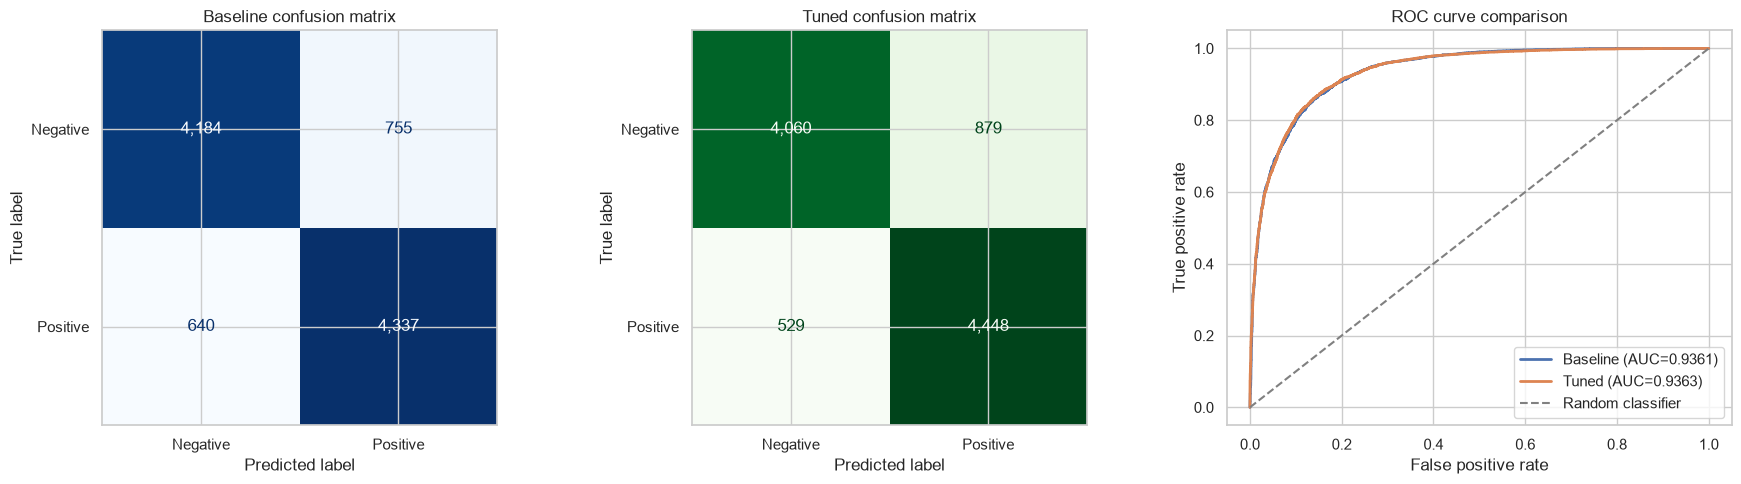

In [25]:
# Compare the error counts and ROC curves of both configurations.
baseline_cm = confusion_matrix(y_test, baseline_pred, labels=[0, 1])
tuned_cm = confusion_matrix(y_test, tuned_pred, labels=[0, 1])
baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_probability)
tuned_fpr, tuned_tpr, _ = roc_curve(y_test, tuned_probability)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=["Negative", "Positive"],
).plot(ax=axes[0], cmap="Blues", colorbar=False, values_format=",d")
axes[0].set_title("Baseline confusion matrix")

ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm,
    display_labels=["Negative", "Positive"],
).plot(ax=axes[1], cmap="Greens", colorbar=False, values_format=",d")
axes[1].set_title("Tuned confusion matrix")

axes[2].plot(
    baseline_fpr,
    baseline_tpr,
    linewidth=2,
    label=f"Baseline (AUC={baseline_metrics['ROC-AUC']:.4f})",
)
axes[2].plot(
    tuned_fpr,
    tuned_tpr,
    linewidth=2,
    label=f"Tuned (AUC={tuned_metrics['ROC-AUC']:.4f})",
)
axes[2].plot([0, 1], [0, 1], "--", color="grey", label="Random classifier")
axes[2].set(
    xlabel="False positive rate",
    ylabel="True positive rate",
    title="ROC curve comparison",
)
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 11. Inspect influential TF-IDF features

Mean decrease in impurity indicates which terms contributed most to the selected forest's decisions. Importance magnitude does **not** show whether a term predicts positive or negative sentiment.

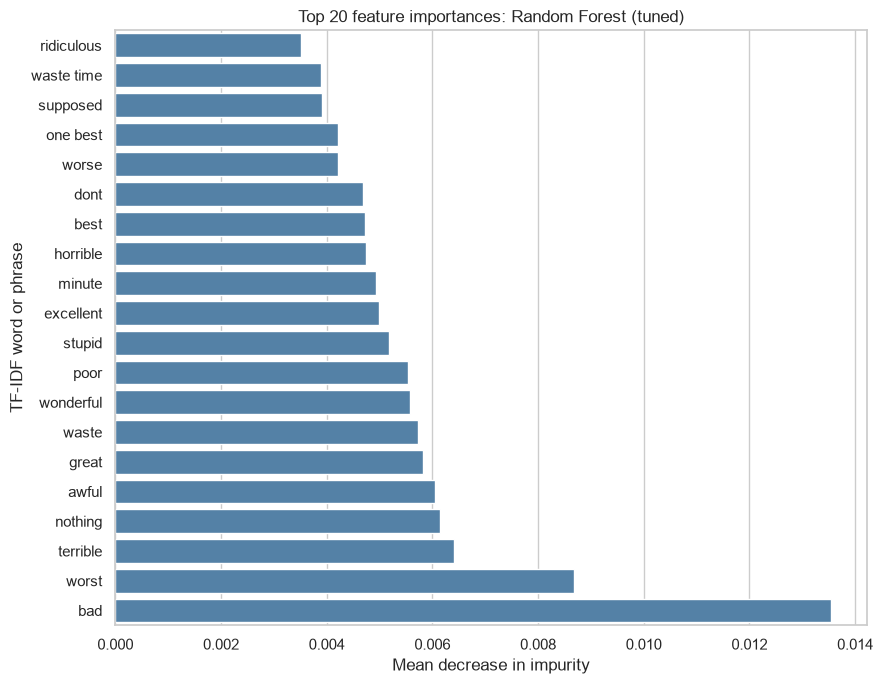

In [26]:
feature_names = selected_pipeline.named_steps["tfidf"].get_feature_names_out()
feature_importances = selected_pipeline.named_steps[
    "random_forest"
].feature_importances_

top_features = (
    pd.DataFrame(
        {"feature": feature_names, "importance": feature_importances}
    )
    .nlargest(20, "importance")
    .sort_values("importance")
)

plt.figure(figsize=(9, 7))
sns.barplot(data=top_features, x="importance", y="feature", color="steelblue")
plt.title(f"Top 20 feature importances: {selected_model_name}")
plt.xlabel("Mean decrease in impurity")
plt.ylabel("TF-IDF word or phrase")
plt.tight_layout()
plt.show()

## 12. Error analysis

Reviewing confidently wrong predictions helps reveal limitations such as mixed opinions, negation, sarcasm, or context lost during text cleaning.

In [27]:
error_df = pd.DataFrame(
    {
        "review": X_test.reset_index(drop=True),
        "actual": y_test.reset_index(drop=True),
        "predicted": selected_pred,
        "positive_probability": selected_probability,
    }
)
error_df = error_df.loc[
    error_df["actual"] != error_df["predicted"]
].copy()
error_df["actual"] = error_df["actual"].map(
    {0: "negative", 1: "positive"}
)
error_df["predicted"] = error_df["predicted"].map(
    {0: "negative", 1: "positive"}
)
error_df["confidence"] = np.where(
    error_df["predicted"].eq("positive"),
    error_df["positive_probability"],
    1 - error_df["positive_probability"],
)

error_sample = (
    error_df.nlargest(min(6, len(error_df)), "confidence")
    .assign(
        positive_probability=lambda frame: frame[
            "positive_probability"
        ].round(4),
        confidence=lambda frame: frame["confidence"].round(4),
    )
)
display(error_sample)

,review,actual,predicted,positive_probability,confidence
1320,jack frost probably cheesiest movie ever seen life complete title film jack frost revenge mutant killer snowman horr...,positive,negative,0.4101,0.5899
4053,movie favorite time supposed plot maker wanted people charlie sheen thinkto believe real snuff film exercise visual ...,positive,negative,0.4138,0.5862
781,lord david cecil wrote interesting book early victorian novelist looked work dickens thackeray eliot trollope mr gas...,negative,positive,0.5845,0.5845
4449,korines established talented impressive imagemaker promotional poster mister lonely include film impressive composit...,negative,positive,0.5802,0.5802
8304,author numerous novel play short story w somerset maugham considered among world great author lifetime although repu...,negative,positive,0.5792,0.5792
2130,largely considered decade horror decided fun sometimes definite brain behind evil dead ii night creep return living ...,positive,negative,0.4218,0.5782


## 13. Critical discussion and model choice

The final cell reports the observed improvement or decline rather than assuming tuning must win. For the later group comparison, every algorithm should use the same cleaned reviews, duplicate policy, split, random state, and metric definitions.

In [28]:
metric_differences = {
    metric: tuned_metrics[metric] - baseline_metrics[metric]
    for metric in [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Macro F1",
        "ROC-AUC",
    ]
}
selected_cm = confusion_matrix(y_test, selected_pred, labels=[0, 1])
tn, fp, fn, tp = selected_cm.ravel()

print("RANDOM FOREST EVALUATION SUMMARY")
print("-" * 44)
print(f"Held-out test reviews : {len(y_test):,}")
print(f"Selected configuration: {selected_model_name}")
print(
    f"Selected F1 / Macro F1: "
    f"{comparison_df.loc[selected_model_name, 'F1-score']:.4f} / "
    f"{comparison_df.loc[selected_model_name, 'Macro F1']:.4f}"
)
print(
    f"Selected accuracy/AUC : "
    f"{comparison_df.loc[selected_model_name, 'Accuracy']:.4f} / "
    f"{comparison_df.loc[selected_model_name, 'ROC-AUC']:.4f}"
)
print(f"Correct / incorrect   : {tn + tp:,} / {fp + fn:,}")
print(f"False positives       : {fp:,}")
print(f"False negatives       : {fn:,}")
print("\nTuned minus baseline test metrics:")
for metric, difference in metric_differences.items():
    print(f"- {metric:<10}: {difference:+.4f}")

print("\nCritical interpretation:")
if metric_differences["F1-score"] > 0:
    print(
        "- The tuned configuration improves positive-class F1 and recall, "
        "but this must be interpreted together with its precision change."
    )
elif metric_differences["F1-score"] < 0:
    print(
        "- The tuned configuration has lower held-out F1. Cross-validation "
        "selection does not guarantee improvement on one unseen test set."
    )
else:
    print("- The two configurations tie on held-out positive-class F1.")

print(
    "- Here, tuning trades some precision for higher recall. Accuracy and "
    "Macro F1 show whether that positive-class gain is accompanied by more "
    "negative-review errors."
)
print(
    "- ROC-AUC measures ranking quality, while the confusion matrices show "
    "the actual false-positive and false-negative counts at threshold 0.5."
)
print(
    "- The tuned forest remains the final Q3 configuration because it was "
    "chosen by the declared training-only CV F1 procedure. The baseline test "
    "row is retained to report the observed trade-off, not to retune on test data."
)
print(
    "- Cross-validation F1 and held-out test F1 come from different samples "
    "and should not be treated as directly interchangeable scores."
)
print(
    "- Only eight combinations on a 12,000-review training subset were "
    "searched to control computation. A larger search could find a different "
    "configuration, so the reported optimum is conditional on this search space."
)
print(
    "- Random Forest can model nonlinear feature interactions and provides "
    "feature importances, but it is computationally heavier than many linear "
    "classifiers on high-dimensional sparse text."
)
print(
    "- The result supports conclusions about this cleaned IMDB split only. "
    "Later group comparison and literature comparison are fair only when "
    "preprocessing, partitions, class definitions, and metrics are comparable."
)

RANDOM FOREST EVALUATION SUMMARY
--------------------------------------------
Held-out test reviews : 9,916
Selected configuration: Random Forest (tuned)
Selected F1 / Macro F1: 0.8634 / 0.8578
Selected accuracy/AUC : 0.8580 / 0.9363
Correct / incorrect   : 8,508 / 1,408
False positives       : 879
False negatives       : 529

Tuned minus baseline test metrics:
- Accuracy  : -0.0013
- Precision : -0.0167
- Recall    : +0.0223
- F1-score  : +0.0019
- Macro F1  : -0.0015
- ROC-AUC   : +0.0002

Critical interpretation:
- The tuned configuration improves positive-class F1 and recall, but this must be interpreted together with its precision change.
- Here, tuning trades some precision for higher recall. Accuracy and Macro F1 show whether that positive-class gain is accompanied by more negative-review errors.
- ROC-AUC measures ranking quality, while the confusion matrices show the actual false-positive and false-negative counts at threshold 0.5.
- The tuned forest remains the final Q3 confi

## 14. Export report-ready results for later model comparison

These compact files let the group compare Random Forest with other members' models without manually copying numbers from notebook outputs.

In [29]:
# Derive the notebook folder from the validated dataset location so exports
# are stable whether Jupyter starts in this folder or at the project root.
artifact_dir = data_path.parents[2] / "Part_B_Q2_Random_Forest"
artifact_dir.mkdir(parents=True, exist_ok=True)

test_results_export = comparison_df.reset_index().copy()
test_results_export["Selected"] = (
    test_results_export["Model"] == selected_model_name
)
test_results_path = artifact_dir / "random_forest_test_results.csv"
tuning_results_path = artifact_dir / "random_forest_tuning_results.csv"
report_path = artifact_dir / "random_forest_classification_report.csv"
parameters_path = artifact_dir / "random_forest_best_parameters.json"

test_results_export.to_csv(test_results_path, index=False)
top_search_results.to_csv(tuning_results_path, index=False)
selected_report_df.to_csv(report_path)

serialisable_parameters = {
    key: value.item() if isinstance(value, np.generic) else value
    for key, value in tuned_rf_parameters.items()
}
with parameters_path.open("w", encoding="utf-8") as parameter_file:
    json.dump(serialisable_parameters, parameter_file, indent=2)

exported_files = pd.DataFrame(
    {
        "Purpose": [
            "Baseline-versus-tuned test metrics",
            "Ranked randomized-search results",
            "Selected model class-wise metrics",
            "Selected tuned hyperparameters",
        ],
        "File": [
            test_results_path.name,
            tuning_results_path.name,
            report_path.name,
            parameters_path.name,
        ],
    }
)
display(exported_files)
print(f"Saved comparison artifacts in: {artifact_dir}")

,Purpose,File
0,Baseline-versus-tuned test metrics,random_forest_test_results.csv
1,Ranked randomized-search results,random_forest_tuning_results.csv
2,Selected model class-wise metrics,random_forest_classification_report.csv
3,Selected tuned hyperparameters,random_forest_best_parameters.json


Saved comparison artifacts in: C:\Users\ggshe\OneDrive - Asia Pacific University of Technology And Innovation (APU)\APU - Year 3\TXSA\source\TSXA\Part_B_Q2_Random_Forest
